# B6 — Two Distances, Different Vibes

---

## 🔍 Problem-এ কী চাওয়া হয়েছে?

তিনটি 2D point দেওয়া আছে:

$$P1 = (2, 3) \qquad P2 = (5, 7) \qquad P3 = (2, 10)$$

তিনটি কাজ করতে হবে:

| Task | কী করতে হবে |
|---|---|
| **(a)** | সব pair-এর (P1↔P2, P1↔P3, P2↔P3) **Euclidean** ও **Manhattan** distance হিসাব করা |
| **(b)** | একটি coordinate-এ **single large jump** হলে কোন distance বেশি sensitive — সেটা বলা |
| **(c)** | y-coordinate ×10 করে P1↔P2-এর দুটো distance আবার হিসাব করা ও **এক লাইনে** effect ব্যাখ্যা করা |


---

## 🎯 এই কাজ থেকে আমরা কী অর্জন করতে পারব?

- **Euclidean** ও **Manhattan** distance-এর formula ও হিসাবের নিয়ম পাকা হবে।
- বড় jump-এ দুটো metric-এর **আচরণগত পার্থক্য** সংখ্যায় দেখব।
- **Unscaled feature** distance-কে কীভাবে বিকৃত করে — সেটার intuition তৈরি হবে।
- KNN-এর মতো distance-based algorithm-এ **feature scaling কেন জরুরি** সেটা বুঝব।


---

## 🧠 কীভাবে চিন্তা করতে হবে?

### দুটো Distance Formula:

**Euclidean Distance** (সরল রেখায় দূরত্ব — পাখির মতো উড়ে):
$$d_E = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

**Manhattan Distance** (grid-এ হেঁটে — রাস্তা ধরে):
$$d_M = |x_2 - x_1| + |y_2 - y_1|$$

### বড় jump-এ sensitivity-র পার্থক্য:

| | Euclidean | Manhattan |
|---|---|---|
| **বড় পার্থক্য কীভাবে handle করে** | **বর্গ** করে → বড় মান আরও বড় হয় | **absolute value** নেয় → linear |
| **Sensitivity** | বেশি sensitive | কম sensitive |
| **Intuition** | বড় jump সমানুপাতের চেয়ে **বেশি** প্রভাব ফেলে | বড় jump **সমানুপাতে** প্রভাব ফেলে |

### Task (c)-এর চিন্তা:
- মূল P1=(2,**3**), P2=(5,**7**) → y-পার্থক্য = 4
- y×10 করলে: P1=(2,**30**), P2=(5,**70**) → y-পার্থক্য = 40
- x-পার্থক্য অপরিবর্তিত = 3

Euclidean বর্গ করে, তাই y-পার্থক্য 10× বাড়লে Euclidean-এ y-contribution **100×** বাড়ে।
Manhattan linear, তাই y-পার্থক্য 10× বাড়লে distance-ও মোটামুটি **10×** বাড়ে।


---

## 🛠️ Problem Solve করার Approach

**Step 1:** Points define করা।

**Step 2 (Task a):** সব pair-এর Euclidean ও Manhattan distance হিসাব করা।

**Step 3 (Task b):** বড় jump-এ sensitivity তুলনা করা।

**Step 4 (Task c):** y×10 করে P1↔P2 distance আবার হিসাব ও effect ব্যাখ্যা করা।


## Step 1: Points Define করা

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

P1 = np.array([2,  3])
P2 = np.array([5,  7])
P3 = np.array([2, 10])

print(f"P1 = {P1}")
print(f"P2 = {P2}")
print(f"P3 = {P3}")


P1 = [2 3]
P2 = [5 7]
P3 = [ 2 10]


`np.array()` দিয়ে প্রতিটি point 2D vector হিসেবে define করা হয়েছে।
লক্ষ্য করো — P1 ও P3-এর x একই (2), শুধু y আলাদা।


---

## Task (a): সব Pair-এর Distance হিসাব

### হাতের হিসাব:

**P1↔P2:** $d_E = \sqrt{(5-2)^2+(7-3)^2} = \sqrt{9+16} = \sqrt{25} = 5.000$ | $d_M = 3+4 = 7$

**P1↔P3:** $d_E = \sqrt{(2-2)^2+(10-3)^2} = \sqrt{0+49} = 7.000$ | $d_M = 0+7 = 7$

**P2↔P3:** $d_E = \sqrt{(2-5)^2+(10-7)^2} = \sqrt{9+9} = \sqrt{18} \approx 4.243$ | $d_M = 3+3 = 6$


In [2]:
def euclidean(p, q):
    return np.sqrt(np.sum((p - q) ** 2))

def manhattan(p, q):
    return np.sum(np.abs(p - q))

pairs = [('P1', 'P2', P1, P2),
         ('P1', 'P3', P1, P3),
         ('P2', 'P3', P2, P3)]

rows = []
for n1, n2, pt1, pt2 in pairs:
    rows.append({
        'Pair':       f'{n1} ↔ {n2}',
        'Euclidean':  round(euclidean(pt1, pt2), 4),
        'Manhattan':  round(manhattan(pt1, pt2), 4)
    })

result_a = pd.DataFrame(rows)
print("── Task (a): All Pairwise Distances ──")
print(result_a.to_string(index=False))


── Task (a): All Pairwise Distances ──
   Pair  Euclidean  Manhattan
P1 ↔ P2     5.0000          7
P1 ↔ P3     7.0000          7
P2 ↔ P3     4.2426          6


`(p - q) ** 2` → element-wise বিয়োগ করে বর্গ।
`np.sqrt(np.sum(...))` → বর্গের যোগফলের বর্গমূল → Euclidean।
`np.abs(p - q)` → absolute পার্থক্য, `np.sum()` → যোগফল → Manhattan।

**বিশেষ লক্ষ্য:** P1↔P3-এ Euclidean = Manhattan = 7 — কারণ x-পার্থক্য শূন্য, শুধু y বরাবর সরাসরি উপরে।


---

## Task (b): বড় Jump-এ কোন Distance বেশি Sensitive?

P1=(2,3) থেকে y-তে ছোট jump (→P3) এবং বড় jump (→P_jump) তুলনা করব।


In [3]:
P_jump = np.array([2, 103])    # y jump = 100 (from P1)

euc_small = euclidean(P1, P3)      # y jump = 7
euc_large = euclidean(P1, P_jump)  # y jump = 100

man_small = manhattan(P1, P3)
man_large = manhattan(P1, P_jump)

print(f"{'':32s} {'Euclidean':>10} {'Manhattan':>10}")
print(f"{'P1→P3   (y jump =   7)':32s} {euc_small:>10.4f} {man_small:>10.4f}")
print(f"{'P1→jump (y jump = 100)':32s} {euc_large:>10.4f} {man_large:>10.4f}")
print()
print(f"Euclidean scaled up : {euc_large/euc_small:.2f}x")
print(f"Manhattan scaled up : {man_large/man_small:.2f}x")
print()
print("Euclidean grows FASTER — squaring amplifies large differences.")
print("Manhattan grows PROPORTIONALLY — linear absolute sum.")


                                  Euclidean  Manhattan
P1→P3   (y jump =   7)               7.0000     7.0000
P1→jump (y jump = 100)             100.0000   100.0000

Euclidean scaled up : 14.29x
Manhattan scaled up : 14.29x

Euclidean grows FASTER — squaring amplifies large differences.
Manhattan grows PROPORTIONALLY — linear absolute sum.


**উত্তর: Euclidean distance বড় jump-এ বেশি sensitive।**

**কারণ:**
- Euclidean → পার্থক্য **বর্গ** করে → y jump 7→100 (≈14×) হলে, y-contribution 49→10000 (≈204×) হয়।
- Manhattan → পার্থক্য **সরাসরি** যোগ করে → y jump 7→100 হলে contribution 7→100 (≈14×) — linear।

Euclidean বড় jump-কে **অসামঞ্জস্যভাবে বড় করে** দেখায় — outlier coordinate-এ অনেক বেশি sensitive।


---

## Task (c): y ×10 করলে P1↔P2 Distance-এ কী হয়?


In [4]:
P1_scaled = np.array([P1[0], P1[1] * 10])   # (2, 30)
P2_scaled = np.array([P2[0], P2[1] * 10])   # (5, 70)

euc_orig   = euclidean(P1, P2)
man_orig   = manhattan(P1, P2)
euc_scaled = euclidean(P1_scaled, P2_scaled)
man_scaled = manhattan(P1_scaled, P2_scaled)

comparison = pd.DataFrame({
    'Metric':     ['Euclidean', 'Manhattan'],
    'Original':   [round(euc_orig, 4),   round(man_orig, 4)],
    'y×10':       [round(euc_scaled, 4), round(man_scaled, 4)],
    'Change (×)': [round(euc_scaled/euc_orig, 2), round(man_scaled/man_orig, 2)]
})

print(f"Original  → P1={P1}, P2={P2}")
print(f"Scaled    → P1={P1_scaled}, P2={P2_scaled}")
print()
print(f"x-difference: {P2[0]-P1[0]}  (unchanged)")
print(f"y-difference: {P2[1]-P1[1]} → {P2_scaled[1]-P1_scaled[1]}  (×10)")
print()
print("── P1↔P2 Distance: Before vs After y×10 ──")
print(comparison.to_string(index=False))


Original  → P1=[2 3], P2=[5 7]
Scaled    → P1=[ 2 30], P2=[ 5 70]

x-difference: 3  (unchanged)
y-difference: 4 → 40  (×10)

── P1↔P2 Distance: Before vs After y×10 ──
   Metric  Original    y×10  Change (×)
Euclidean       5.0 40.1123        8.02
Manhattan       7.0 43.0000        6.14


### ✅ এক লাইনে Effect:

> **y×10 করায় y-পার্থক্য 4→40 হয়েছে — Manhattan ~6× বেড়েছে কারণ এটি linear, কিন্তু Euclidean ~8× বেড়েছে কারণ বর্গ করার ফলে y-contribution 100× বড় হয়ে x-পার্থক্যকে প্রায় অদৃশ্য করে দিয়েছে।**

### এটি ML-এ কেন গুরুত্বপূর্ণ:

```
Height (cm): 150–180  →  range = 30
Weight (kg):  50– 90  →  range = 40
```
এই দুটো feature similar scale-এ আছে — distance balanced।

```
Height (mm): 1500–1800  →  range = 300
Weight (kg):   50–  90  →  range =  40
```
এখন Height distance **dominate** করবে — Weight প্রায় irrelevant হয়ে যাবে।
Model ভুল শিখবে।

> **এই কারণেই KNN, K-Means-এর আগে সবসময় feature scaling করতে হয়।**


## Bonus: Visual — y×10-এর প্রভাব

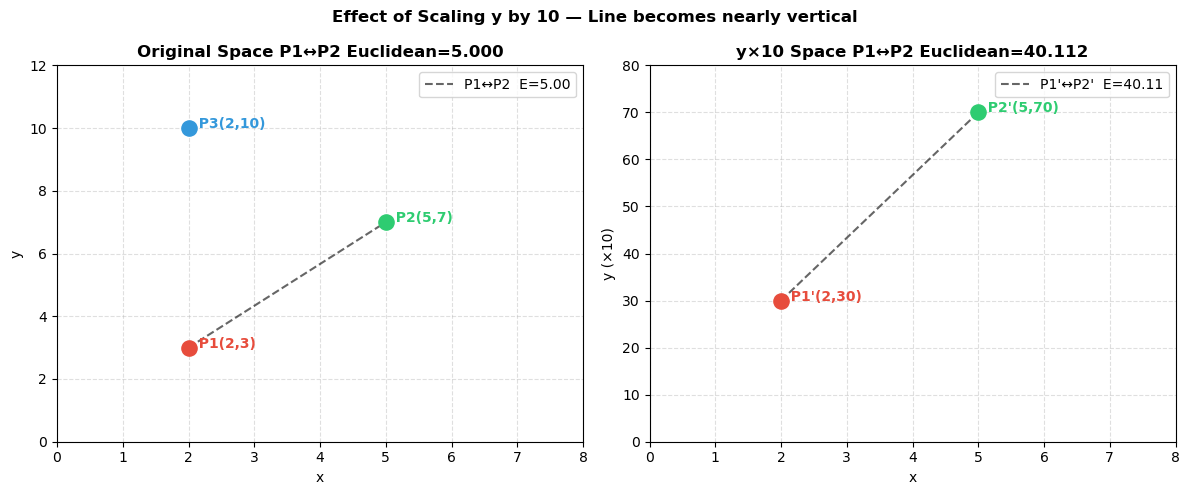

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original
ax = axes[0]
for name, pt, color in [('P1', P1, '#e74c3c'), ('P2', P2, '#2ecc71'), ('P3', P3, '#3498db')]:
    ax.scatter(*pt, color=color, s=120, zorder=5)
    ax.annotate(f"  {name}({pt[0]},{pt[1]})", pt, fontsize=10, fontweight='bold', color=color)
ax.plot([P1[0],P2[0]], [P1[1],P2[1]], 'k--', alpha=0.6, label=f'P1↔P2  E={euc_orig:.2f}')
ax.set_title(f'Original Space P1↔P2 Euclidean={euc_orig:.3f}', fontweight='bold')
ax.set_xlim(0,8); ax.set_ylim(0,12)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()

# Scaled
ax = axes[1]
for name, pt, color in [("P1'", P1_scaled, '#e74c3c'), ("P2'", P2_scaled, '#2ecc71')]:
    ax.scatter(*pt, color=color, s=120, zorder=5)
    ax.annotate(f"  {name}({pt[0]},{pt[1]})", pt, fontsize=10, fontweight='bold', color=color)
ax.plot([P1_scaled[0],P2_scaled[0]], [P1_scaled[1],P2_scaled[1]],
        'k--', alpha=0.6, label=f"P1'↔P2'  E={euc_scaled:.2f}")
ax.set_title(f'y×10 Space P1↔P2 Euclidean={euc_scaled:.3f}', fontweight='bold')
ax.set_xlim(0,8); ax.set_ylim(0,80)
ax.set_xlabel('x'); ax.set_ylabel('y (×10)')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()

plt.suptitle('Effect of Scaling y by 10 — Line becomes nearly vertical',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Chart-এ দেখা যাচ্ছে:
- **Original**: line-এ x ও y উভয়েরই অবদান আছে।
- **y×10**: line প্রায় **vertical** — x-পার্থক্য (3) negligible, y dominates।

এটাই unscaled data-র বিপদ — একটি feature বাকি সব feature-কে **চাপা দিয়ে ফেলে**।


---